# Unsupervised Learning: K-Means Clustering

This notebook demonstrates how to use K-Means clustering and Principal Component Analysis (PCA) in `scikit-learn`.

We use toy datasets of synthetic generated data so that we can focus on the techniques. We will pick up the physics applications on the Hands-On session on Friday.

By the way, you will not need a T4 TPU runtime type for this notebook. The unsupervised learning examples here are very short and not very CPU-intensive.

## K-Means Clustering

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

np.random.seed(42)

### Generate data for unsupervised learning with K-Means

There is a standard `make_blobs` method in scikit-learn, so we'll use that.

We will generate data in 2 dimensions (2 features), and we will generate the data in such a way that we have 3 natural clusters.

The 3 clusters are readily apparent in this visualization.

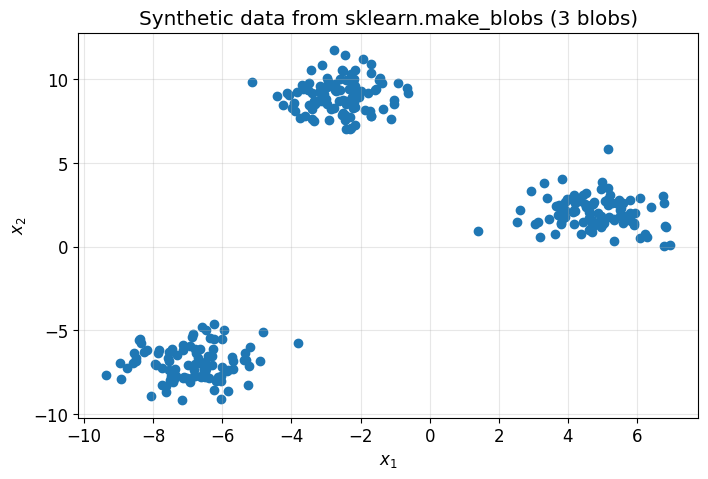

In [8]:
# This call generates 300 points, 3 clusters, 2 features
X_blobs, y_true = make_blobs(n_samples=300, centers=3, n_features=2,
                              cluster_std=1.0, random_state=42)

plt.scatter(X_blobs[:, 0], X_blobs[:, 1])
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Synthetic data from sklearn.make_blobs (3 blobs)')
plt.show()

### Fit K-Means (Cluster)

In principle there are three steps (create, fit, and predict), but the last two are combined in scikit-learn.

The predict step gives each data point a cluster label. This defines which cluster the data point belongs in.

We can get the cluster center information and plot the locations.

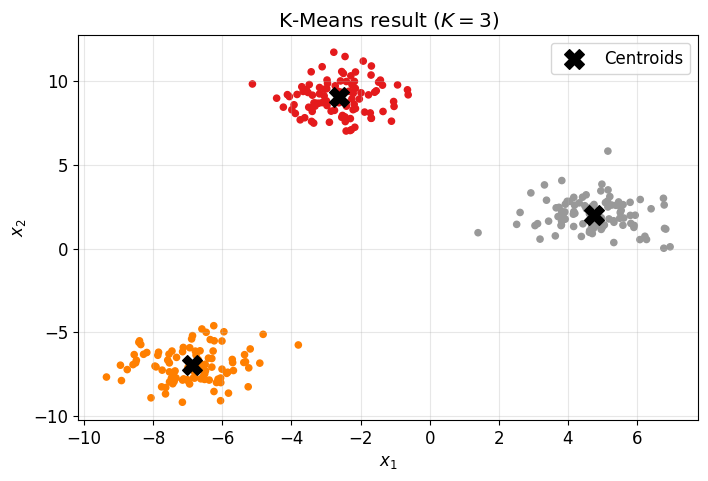

In [12]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_blobs)

# Plot the result
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels, cmap='Set1', s=20)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='black', marker='X', s=200, label='Centroids')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('K-Means result ($K=3$)')
plt.legend()
plt.show()

After we have fit the `KMeans` object to the data, we can access several useful quantities, like the cluster shape, the variance within the clusters, and the label associated with each data point.

In [14]:
print("Cluster centers (shape {}):".format(kmeans.cluster_centers_.shape))
print(kmeans.cluster_centers_)

print("Inertia (total within-cluster variance):", f"{kmeans.inertia_:.1f}")

print("Labels (first 10):", kmeans.labels_[:10])

print("Number of iterations:", kmeans.n_iter_)

Cluster centers (shape (3, 2)):
[[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]
Inertia (total within-cluster variance): 566.9
Labels (first 10): [1 1 0 2 1 2 0 2 0 0]
Number of iterations: 2


### Checking K value

For the "elbow method," we pick a K value for which the inertia is small. If the inertia is large, it means that the points assigned to a cluster are far apart. For large K values the cluster is split arbitrarily, so it doesn't improve the inertia score very much.

The `silhouette_score` is calculated by scikit-learn. It measures how well each data point fits within its assigned cluster compared to neighboring clusters.
If $a(i)$ is the average distance to points in the same cluster and $b(i)$ is the average distance to points in the nearest cluster, then

$$s(i) = \frac{b(i)-a(i)}{\max(a(i) b(i))}$$

A value near
+1 means the point is well inside its own cluster and far from others. A value near 0 means it's on the boundary between two clusters. A negative value means it's probably in the wrong cluster.

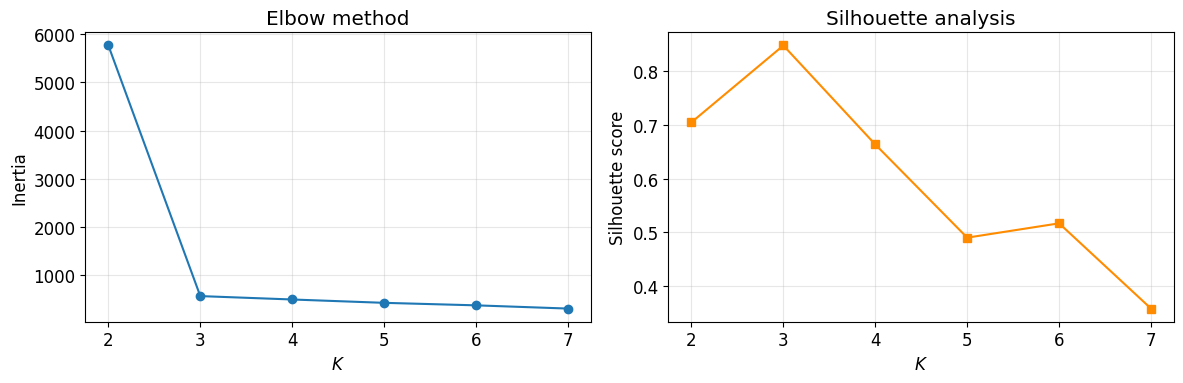

In [15]:
K_range = range(2, 8)
inertias = []
silhouettes = []

for K in K_range:
    km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X_blobs)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_blobs, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, 'o-')
axes[0].set_xlabel('$K$')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method')

axes[1].plot(list(K_range), silhouettes, 's-', color='darkorange')
axes[1].set_xlabel('$K$')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette analysis')

plt.tight_layout()
plt.show()

It's no surprise that $K=3$ is the best for these data generated with `n_clusters=3`.


Keep in mind that the K-means clustering algorithm will partition the data into exactly the $K$ clusters you ask for, even if that's not the natural number.

Since we can get the cluster_centers from the K-means clustering, we can check visually what happens as we try to increase the value of $K$.
It is clear why $K=2$ gives a high inertia score and why $K>3$ yields a low silhouette score.

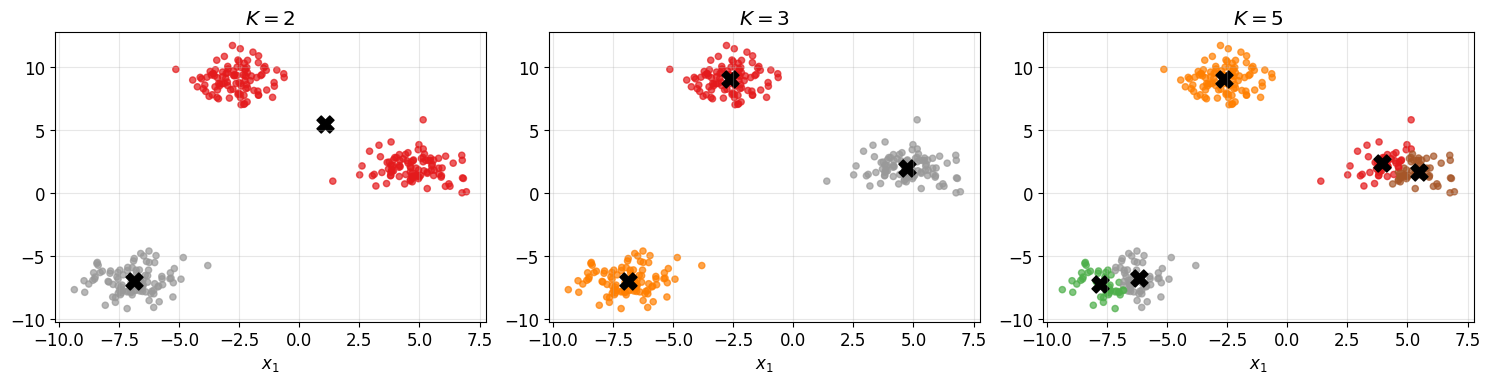

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, K in zip(axes, [2, 3, 5]):
    km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X_blobs)
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=km.labels_, cmap='Set1', s=20, alpha=0.7)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c='black', marker='X', s=150)
    ax.set_title(f'$K = {K}$')
    ax.set_xlabel('$x_1$')

plt.tight_layout()
plt.show()

The K-means clustering can of course be used in higher dimensions (greater number of features).

# Unsupervised Learning: Principal Component Analysis (PCA)

In this example we create 5-dimensional data that is grown from a 2D plane, then add some noise. PCA should recover that original low-dimensional structure.

In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Introduce two "true" latent variables
n_samples = 500
z1 = np.random.randn(n_samples)
z2 = np.random.randn(n_samples)

Z = np.column_stack([z1, z2])

# Extend these variables to 5 dimensions via a fixed arbitrary mixing matrix A
A = np.array([[2, 1],
              [1, 3],
              [1, 1],
              [0.5, -1],
              [-1, 0.5]])

# Add noise so that the extension is not trivially learned
X_5d = Z @ A.T + 0.3 * np.random.randn(n_samples, 5)

print(f"Data shape: {X_5d.shape}  (500 samples, 5 features)")

Data shape: (500, 5)  (500 samples, 5 features)


The `StandardScaler` standardizes features by removing the mean and scaling to unit variance.
This is a good practice before PCA; otherwise feature with large scales could dominate unexpectedly.

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_5d)

### Fit PCA

After the fit we can inspect the variance of the resulting components.

In [28]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio per component:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.4f}")


Explained variance ratio per component:
  PC1: 0.5757
  PC2: 0.4029
  PC3: 0.0118
  PC4: 0.0061
  PC5: 0.0036


We can see from these results that the first two Principal Components explain 97.7% of variance. This is not unexpected with two free variables.

### Visualize projection onto first 2 components

Since the data was generated from 2 original variables, the first 2 PCs should capture almost everything.

The "scree plot" shows the fraction of variance explained by each principal component. The idea is that the first few components capture the real structure in the data, and then there is a fall-off (the "scree").

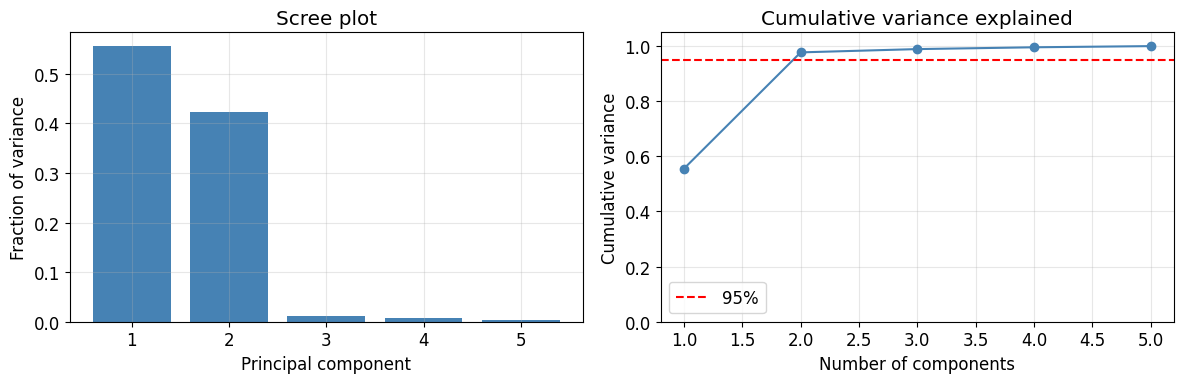

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
axes[0].bar(range(1, 6), pca.explained_variance_ratio_, color='steelblue')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Fraction of variance')
axes[0].set_title('Scree plot')

# Cumulative
axes[1].plot(range(1, 6), np.cumsum(pca.explained_variance_ratio_), 'o-', color='steelblue')
axes[1].axhline(0.95, color='red', linestyle='--', label='95%')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance')
axes[1].set_title('Cumulative variance explained')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

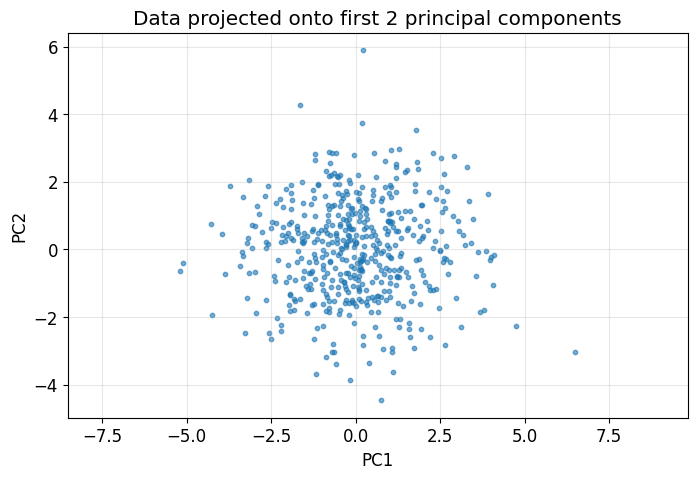

In [22]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Data projected onto first 2 principal components')
plt.axis('equal')
plt.show()

### Interpretability

The PCA components ("loadings") tell you how each original feature contributes to each PC.
This can be useful for understanding the underlying data structure.

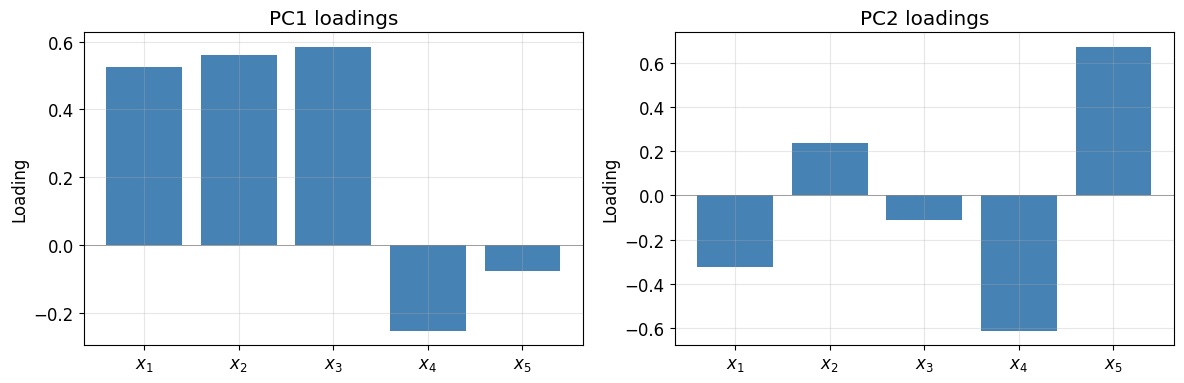

In [23]:
feature_names = [f'$x_{i+1}$' for i in range(5)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, i in zip(axes, [0, 1]):
    ax.bar(feature_names, pca.components_[i], color='steelblue')
    ax.set_ylabel('Loading')
    ax.set_title(f'PC{i+1} loadings')
    ax.axhline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

### Reconstruction from components: how many components do we need?

`pca.inverse_transform` maps back from PC space to the original feature space.
With exactly 5 components, the reconstruction should be perfect.
With fewer components, the reconstruction is approximate.

In [24]:
# Compare reconstruction error for different numbers of components
for n_comp in [1, 2, 3, 5]:
    pca_n = PCA(n_components=n_comp).fit(X_scaled)
    X_recon = pca_n.inverse_transform(pca_n.transform(X_scaled))
    mse = np.mean((X_scaled - X_recon) ** 2)
    print(f"  {n_comp} component(s):  MSE = {mse:.4f}")

  1 component(s):  MSE = 0.4445
  2 component(s):  MSE = 0.0227
  3 component(s):  MSE = 0.0108
  5 component(s):  MSE = 0.0000
